In [1]:
suppressWarnings(suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(ggplot2)
  library(cowplot)
  library(purrr)
  library(grid)
}))

## plot parameters

In [2]:
metric_pal <- c(
  "dists" = "#1F78B4",
  "lpips" = "#5E3C99",
  "foreground_ssim" = "#66C2A5",
  "ssim" = "#1B9E77",
  "foreground_psnr" = "#FDB863",
  "psnr" = "#E66101",
  "mae" = "#9E9E9E"
)

metric_order <- c(
  "dists",
  "lpips",
  "foreground_ssim",
  "ssim",
  "foreground_psnr",
  "psnr",
  "mae"
)

ablation_shapes <- c(
  "Dilate" = 16,
  "Erode" = 17,
  "GaussianBlur" = 15,
  "GaussNoise" = 18,
  "GridDistortion" = 8,
  "RandomGamma" = 9
)

## Read in plot data

In [3]:
cell_summary <- read_csv(
  "results/boot_nest_cell_line_summary.csv",
  show_col_types = FALSE
) %>%
  mutate(
    nest_condition = "Cell line",
    metric_name = factor(metric_name, levels = metric_order),
    ablation_type = factor(ablation_type, levels = names(ablation_shapes))
  )

confluence_summary <- read_csv(
  "results/boot_nest_confluence_summary.csv",
  show_col_types = FALSE
) %>%
  mutate(
    nest_condition = "Seeding density / confluence",
    metric_name = factor(metric_name, levels = metric_order),
    ablation_type = factor(ablation_type, levels = names(ablation_shapes))
  )

panel_b_df <- bind_rows(cell_summary, confluence_summary)
head(panel_b_df)

metric_name,ablation_type,n_boot,restricted_r2_mean,restricted_r2_lower,restricted_r2_upper,partial_r2_mean,partial_r2_lower,partial_r2_upper,nest_condition
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
dists,Dilate,300,0.49819268,0.49048096,0.50627887,0.11015923,0.10286935,0.11853194,Cell line
dists,Erode,300,0.32125569,0.30285389,0.34073576,0.12689280,0.11186845,0.14160488,Cell line
dists,GaussNoise,300,0.17446497,0.16463906,0.18330265,0.02831965,0.02430891,0.03269470,Cell line
dists,GaussianBlur,300,0.07270553,0.06675789,0.07851808,0.04614541,0.04079802,0.05115599,Cell line
dists,GridDistortion,300,0.57180562,0.56366856,0.58153606,0.05234623,0.04706264,0.05832741,Cell line
dists,RandomGamma,300,0.35725885,0.34711751,0.36770330,0.01778090,0.01538833,0.02028809,Cell line


## Plot helpers

In [4]:
plot_r2_colored_by_metric <- function(
  df,
  xlim = NULL,
  ylim = NULL,
  show_legend = TRUE,
  hide_x = FALSE,
  hide_y = FALSE
) {
  p <- ggplot(
    df,
    aes(
      x = restricted_r2_mean,
      y = partial_r2_mean,
      color = metric_name
    )
  ) +
    geom_errorbar(
      aes(ymin = partial_r2_lower, ymax = partial_r2_upper),
      width = 0,
      alpha = 0.55,
      linewidth = 0.35
    ) +
    geom_segment(
      aes(
        x = restricted_r2_lower,
        xend = restricted_r2_upper,
        y = partial_r2_mean,
        yend = partial_r2_mean
      ),
      alpha = 0.55,
      linewidth = 0.35
    ) +
    geom_point(size = 2.4, alpha = 0.95) +
    scale_color_manual(
      values = metric_pal,
      breaks = metric_order,
      drop = FALSE
    ) +
    coord_cartesian(xlim = xlim, ylim = ylim, expand = TRUE) +
    labs(x = NULL, y = NULL, color = NULL) +
    theme_bw(base_size = 10.5) +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "grey90", linewidth = 0.28),
      legend.position = "right",
      legend.key.height = unit(0.35, "cm"),
      legend.text = element_text(size = 8.5),
      axis.title = element_blank(),
      axis.text = element_text(size = 8.5)
    )

  if (!show_legend) {
    p <- p + guides(color = "none")
  }

  if (hide_x) {
    p <- p + theme(
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank()
    )
  }

  if (hide_y) {
    p <- p + theme(
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank()
    )
  }

  p
}

In [5]:
plot_r2_shaped_by_ablation <- function(
  df,
  xlim = NULL,
  ylim = NULL,
  show_legend = TRUE,
  point_color = "grey20",
  hide_x = FALSE,
  hide_y = FALSE
) {
  p <- ggplot(
    df,
    aes(
      x = restricted_r2_mean,
      y = partial_r2_mean,
      shape = ablation_type
    )
  ) +
    geom_errorbar(
      aes(ymin = partial_r2_lower, ymax = partial_r2_upper),
      width = 0,
      color = point_color,
      alpha = 0.50,
      linewidth = 0.35
    ) +
    geom_segment(
      aes(
        x = restricted_r2_lower,
        xend = restricted_r2_upper,
        y = partial_r2_mean,
        yend = partial_r2_mean
      ),
      color = point_color,
      alpha = 0.50,
      linewidth = 0.35
    ) +
    geom_point(
      color = point_color,
      size = 2.6,
      alpha = 0.95
    ) +
    scale_shape_manual(
      values = ablation_shapes,
      breaks = names(ablation_shapes),
      drop = FALSE
    ) +
    coord_cartesian(xlim = xlim, ylim = ylim, expand = TRUE) +
    labs(x = NULL, y = NULL, shape = NULL) +
    theme_bw(base_size = 10.5) +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "grey90", linewidth = 0.28),
      legend.position = "right",
      legend.key.height = unit(0.35, "cm"),
      legend.text = element_text(size = 8.5),
      axis.title = element_blank(),
      axis.text = element_text(size = 8.5)
    )

  if (!show_legend) {
    p <- p + guides(shape = "none")
  }

  if (hide_x) {
    p <- p + theme(
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank()
    )
  }

  if (hide_y) {
    p <- p + theme(
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank()
    )
  }

  p
}

## Produce plots for two confounders

In [6]:
# Shared axis limits across both summary files
xlim_shared <- c(
  0,
  min(1, max(panel_b_df$restricted_r2_upper, na.rm = TRUE) * 1.05)
)

ylim_shared <- c(
  0,
  min(1, max(panel_b_df$partial_r2_upper, na.rm = TRUE) * 1.05)
)

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


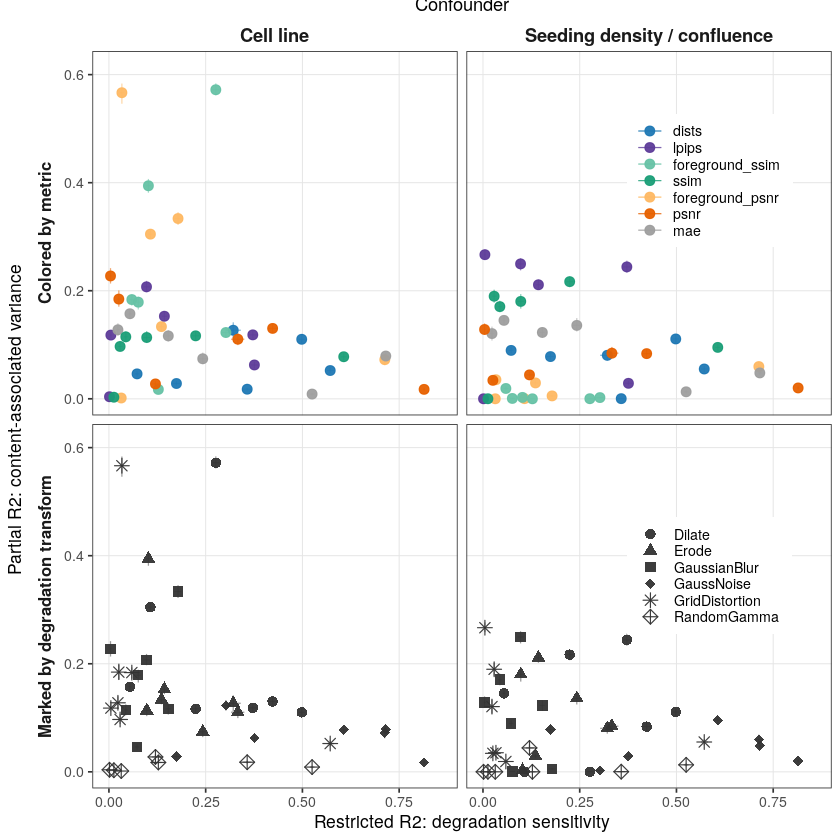

In [7]:
panel_metric_df <- panel_b_df %>%
  mutate(plot_type = "Colored by metric")

panel_ablation_df <- panel_b_df %>%
  mutate(plot_type = "Marked by degradation transform")

panel_base <- ggplot() +
  geom_errorbar(
    data = panel_metric_df,
    aes(
      x = restricted_r2_mean,
      y = partial_r2_mean,
      ymin = partial_r2_lower,
      ymax = partial_r2_upper,
      color = metric_name
    ),
    width = 0,
    alpha = 0.55,
    linewidth = 0.35
  ) +
  geom_segment(
    data = panel_metric_df,
    aes(
      x = restricted_r2_lower,
      xend = restricted_r2_upper,
      y = partial_r2_mean,
      yend = partial_r2_mean,
      color = metric_name
    ),
    alpha = 0.55,
    linewidth = 0.35
  ) +
  geom_point(
    data = panel_metric_df,
    aes(
      x = restricted_r2_mean,
      y = partial_r2_mean,
      color = metric_name
    ),
    size = 2.4,
    alpha = 0.95
  ) +
  geom_errorbar(
    data = panel_ablation_df,
    aes(
      x = restricted_r2_mean,
      y = partial_r2_mean,
      ymin = partial_r2_lower,
      ymax = partial_r2_upper
    ),
    width = 0,
    color = "grey20",
    alpha = 0.50,
    linewidth = 0.35
  ) +
  geom_segment(
    data = panel_ablation_df,
    aes(
      x = restricted_r2_lower,
      xend = restricted_r2_upper,
      y = partial_r2_mean,
      yend = partial_r2_mean
    ),
    color = "grey20",
    alpha = 0.50,
    linewidth = 0.35
  ) +
  geom_point(
    data = panel_ablation_df,
    aes(
      x = restricted_r2_mean,
      y = partial_r2_mean,
      shape = ablation_type
    ),
    color = "grey20",
    size = 2.6,
    alpha = 0.95
  ) +
  facet_grid(
    plot_type ~ nest_condition,
    switch = "y"
  ) +
  scale_color_manual(
    values = metric_pal,
    breaks = metric_order,
    drop = FALSE
  ) +
  scale_shape_manual(
    values = ablation_shapes,
    breaks = names(ablation_shapes),
    drop = FALSE
  ) +
  coord_cartesian(xlim = xlim_shared, ylim = ylim_shared, expand = TRUE) +
  labs(
    x = "Restricted R2: degradation sensitivity",
    y = "Partial R2: content-associated variance",
    color = NULL,
    shape = NULL
  ) +
  theme_bw(base_size = 10.5) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.28),
    axis.title = element_text(size = 10.5),
    axis.text = element_text(size = 8.5),
    strip.placement = "outside",
    strip.background = element_blank(),
    strip.text.x = element_text(size = 11, face = "bold"),
    strip.text.y.left = element_text(size = 10, face = "bold"),
    legend.position = "none",
    plot.margin = margin(t = 12, r = 5, b = 5, l = 5)
  )

p_metric_legend <- plot_r2_colored_by_metric(
  panel_b_df %>% filter(nest_condition == "Cell line"),
  xlim = xlim_shared,
  ylim = ylim_shared,
  show_legend = TRUE
)

p_ablation_legend <- plot_r2_shaped_by_ablation(
  panel_b_df %>% filter(nest_condition == "Cell line"),
  xlim = xlim_shared,
  ylim = ylim_shared,
  show_legend = TRUE
)

legend_metric <- get_legend(
  p_metric_legend + theme(legend.position = "right")
)

legend_ablation <- get_legend(
  p_ablation_legend + theme(legend.position = "right")
)

panel_B <- ggdraw() +
  draw_plot(panel_base, 0, 0, 1, 1) +
  draw_label("Confounder", x = 0.55, y = 0.995, size = 11) +
  draw_grob(legend_metric, x = 0.70, y = 0.60, width = 0.29, height = 0.37) +
  draw_grob(legend_ablation, x = 0.70, y = 0.13, width = 0.29, height = 0.37)

panel_B

In [8]:
ggsave(
  filename = "plots/fig_panels/panel_B_harmonized_nested_regression.pdf",
  plot = panel_B,
  width = 8,
  height = 8,
  units = "in",
  device = cairo_pdf,
  create.dir = TRUE
)

ggsave(
  filename = "plots/fig_panels/panel_B_harmonized_nested_regression.png",
  plot = panel_B,
  width = 8,
  height = 8,
  units = "in",
  dpi = 300,
  create.dir = TRUE
)